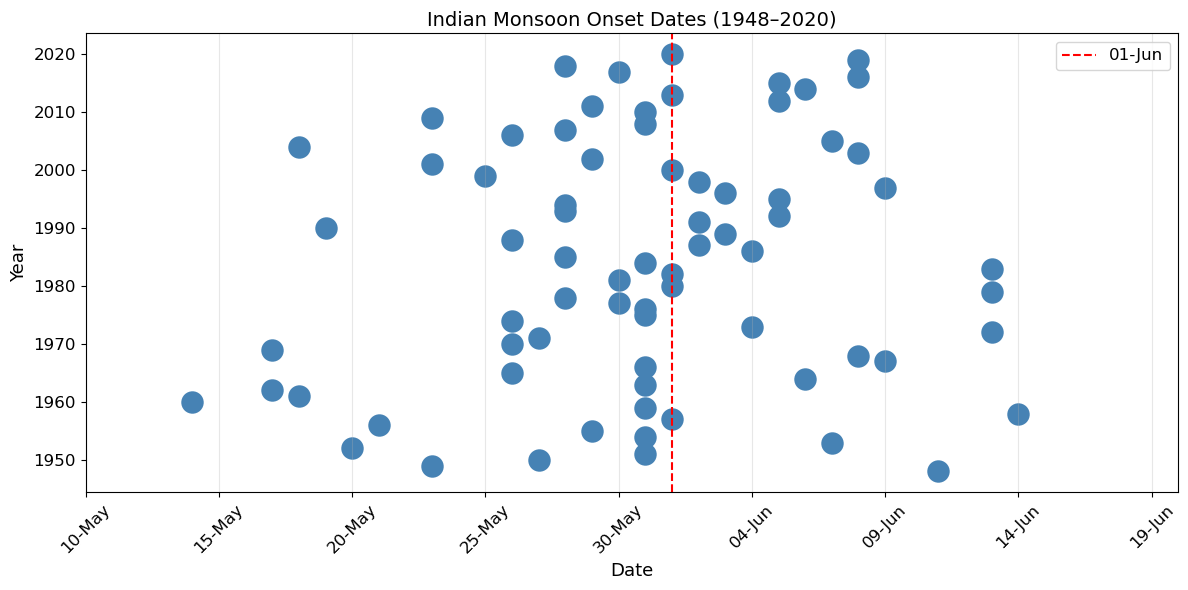

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np


od_time = np.array([
    '1948-06-11', '1949-05-23', '1950-05-27', '1951-05-31', '1952-05-20',
    '1953-06-07', '1954-05-31', '1955-05-29', '1956-05-21', '1957-06-01',
    '1958-06-14', '1959-05-31', '1960-05-14', '1961-05-18', '1962-05-17',
    '1963-05-31', '1964-06-06', '1965-05-26', '1966-05-31', '1967-06-09',
    '1968-06-08', '1969-05-17', '1970-05-26', '1971-05-27', '1972-06-13',
    '1973-06-04', '1974-05-26', '1975-05-31', '1976-05-31', '1977-05-30',
    '1978-05-28', '1979-06-13', '1980-06-01', '1981-05-30', '1982-06-01',
    '1983-06-13', '1984-05-31', '1985-05-28', '1986-06-04', '1987-06-02',
    '1988-05-26', '1989-06-03', '1990-05-19', '1991-06-02', '1992-06-05',
    '1993-05-28', '1994-05-28', '1995-06-05', '1996-06-03', '1997-06-09',
    '1998-06-02', '1999-05-25', '2000-06-01', '2001-05-23', '2002-05-29',
    '2003-06-08', '2004-05-18', '2005-06-07', '2006-05-26', '2007-05-28',
    '2008-05-31', '2009-05-23', '2010-05-31', '2011-05-29', '2012-06-05',
    '2013-06-01', '2014-06-06', '2015-06-05', '2016-06-08', '2017-05-30',
    '2018-05-28', '2019-06-08', '2020-06-01'
], dtype='datetime64[ns]')

# Convert to pandas datetime
dates = pd.to_datetime(od_time)

# Normalize all to a single reference year (2000) to plot on same axis
dates_normalized = pd.to_datetime([f"2000-{d.month:02d}-{d.day:02d}" for d in dates])
years = dates.year

fig, ax = plt.subplots(figsize=(12, 6))

# Plot each date as a marker, y-axis = year
ax.scatter(dates_normalized, years, marker='o', s=200, linewidths=2, color='steelblue')

# Add a vertical line for climatological mean onset (e.g. June 1)
ax.axvline(pd.Timestamp("2000-06-01"), color='red', linestyle='--', linewidth=1.5, label='01-Jun')

# Format x-axis as calendar dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

ax.set_xlim(pd.Timestamp("2000-05-10"), pd.Timestamp("2000-06-20"))
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Year', fontsize=13)
ax.set_title('Indian Monsoon Onset Dates (1948–2020)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

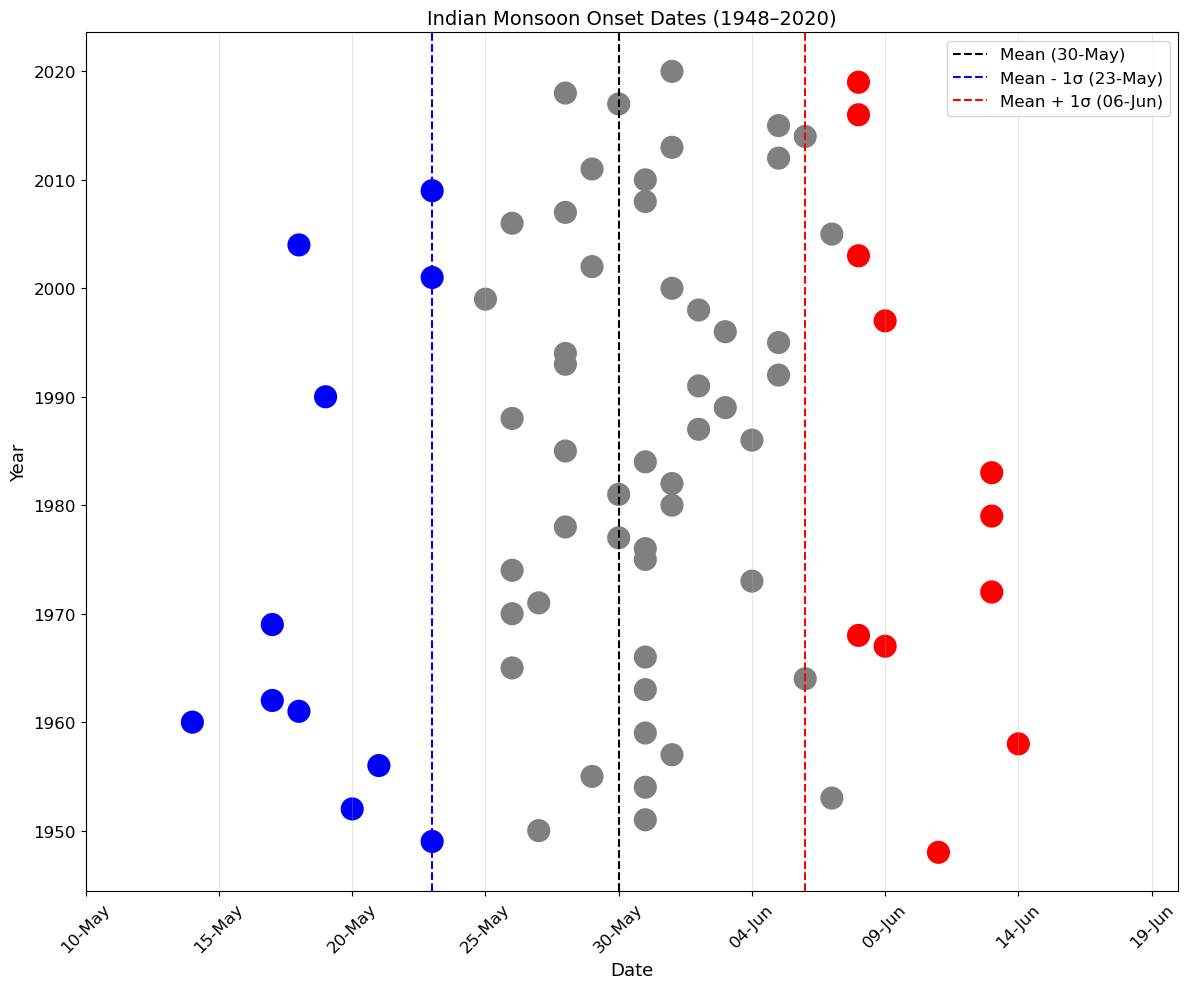

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Convert to pandas datetime
dates = pd.to_datetime(od_time)

# Normalize all to a single reference year (2000) to plot on same axis
dates_normalized = pd.to_datetime([f"2000-{d.month:02d}-{d.day:02d}" for d in dates])
years = dates.year

# Compute mean and std in day-of-year space
doy = np.array([d.timetuple().tm_yday for d in dates])
mean_doy = np.mean(doy)
std_doy  = np.std(doy)

# Classify
colors = []
for d in doy:
    if d < mean_doy - std_doy:
        colors.append('blue')    # early
    elif d > mean_doy + std_doy:
        colors.append('red')     # late
    else:
        colors.append('gray')    # normal

# Reference lines
mean_date  = pd.Timestamp(f"2000-01-01") + pd.Timedelta(days=int(mean_doy)-1)
early_date = pd.Timestamp(f"2000-01-01") + pd.Timedelta(days=int(mean_doy - std_doy)-1)
late_date  = pd.Timestamp(f"2000-01-01") + pd.Timedelta(days=int(mean_doy + std_doy)-1)

fig, ax = plt.subplots(figsize=(12, 10))

ax.scatter(dates_normalized, years, marker='o', s=200, linewidths=2.5, c=colors)

# Reference vertical lines
ax.axvline(mean_date,  color='black', linestyle='--', linewidth=1.5, label=f'Mean ({mean_date.strftime("%d-%b")})')
ax.axvline(early_date, color='blue',  linestyle='--', linewidth=1.5, label=f'Mean - 1σ ({early_date.strftime("%d-%b")})')
ax.axvline(late_date,  color='red',   linestyle='--', linewidth=1.5, label=f'Mean + 1σ ({late_date.strftime("%d-%b")})')

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

ax.set_xlim(pd.Timestamp("2000-05-10"), pd.Timestamp("2000-06-20"))
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Year', fontsize=13)
ax.set_title('Indian Monsoon Onset Dates (1948–2020)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()